In [8]:
import os
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np


In [5]:

# Step 1: List all .fit and .fits files in a directory
def list_fits_files(directory):
    fits_files = []
    for file in os.listdir(directory):
        if file.endswith(".fit") or file.endswith(".fits"):
            #fits_files.append(os.path.join(directory, file))  # add full path
            fits_files.append(file)  # add full path
    return fits_files

# Step 2: Read the header of each file in the array
def read_fits_headers(fits_files):
    headers = []
    for fits_file in fits_files:
        with fits.open(fits_file) as hdul:
            header = hdul[0].header  # Read the primary header (index 0)
            headers.append(header)
    return headers

# Example usage
directory = "/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data"  # Replace with the path to your FITS files
fits_files =list_fits_files(directory)  # Step 1: Get the list of FITS files
print(fits_files)
headers = read_fits_headers(fits_files)  # Step 2: Read the headers
print(headers)
# Print out the file names and corresponding headers
for i, header in enumerate(headers):
    print(f"File: {fits_files[i]}")
    print(header)
    print('-' * 50)


['0s_dark_p_26C.fit', '60s_dark_p_5c_4.fit', '0s_dark_p_20c.fit', '100s_dark_p_26c.fit', '60s_dark_p_0c_5.fit', '60s_dark_m_10c_000.fit', '60s_dark_m_10c.fit', '60s_dark_p_15c2.fit', '0s_dark_m_10c.fit', '60s_dark_m_10c_7.fit', '60s_dark_m_5c_6.fit', '60s_dark_p_10c_3.fit', '60s_dark_p_20c_001.fit', '0s_dark_m_0c.fit']


FileNotFoundError: [Errno 2] No such file or directory: '0s_dark_p_26C.fit'

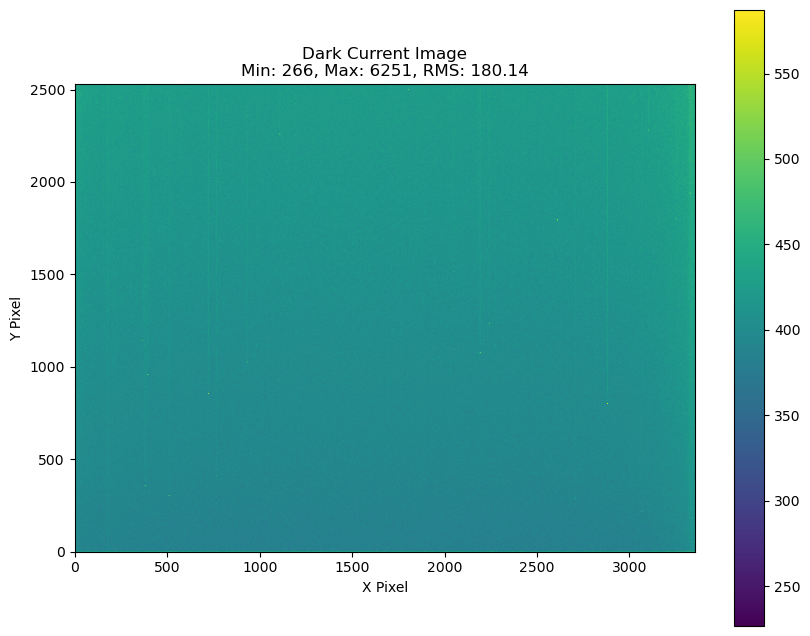

Min: 266, Max: 6251, RMS: 180.14113050417296


In [9]:


# Step 1: Open the FITS file and extract the image data
file_path = '/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit'
with fits.open(file_path) as hdul:
    image_data = hdul[0].data  # Extract the image data

image_min = np.min(image_data)
image_max = np.max(image_data)
rms_value = np.sqrt(np.mean(np.square(image_data)))


# Adjust vmin and vmax for better contrast
vmin = np.median(image_data) - rms_value
vmax = np.median(image_data) + rms_value

# Step 2: Plot the image
plt.figure(figsize=(10, 8))
plt.imshow(image_data, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)  # Scale using RMS around the median
plt.colorbar()
plt.title(f'Dark Current Image\nMin: {image_min}, Max: {image_max}, RMS: {rms_value:.2f}')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

# Print min, max, and RMS for reference
print(f"Min: {image_min}, Max: {image_max}, RMS: {rms_value}")


['/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit']
['/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit']
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit
Min: 266, Max: 6251, RMS: 180.14113050417296


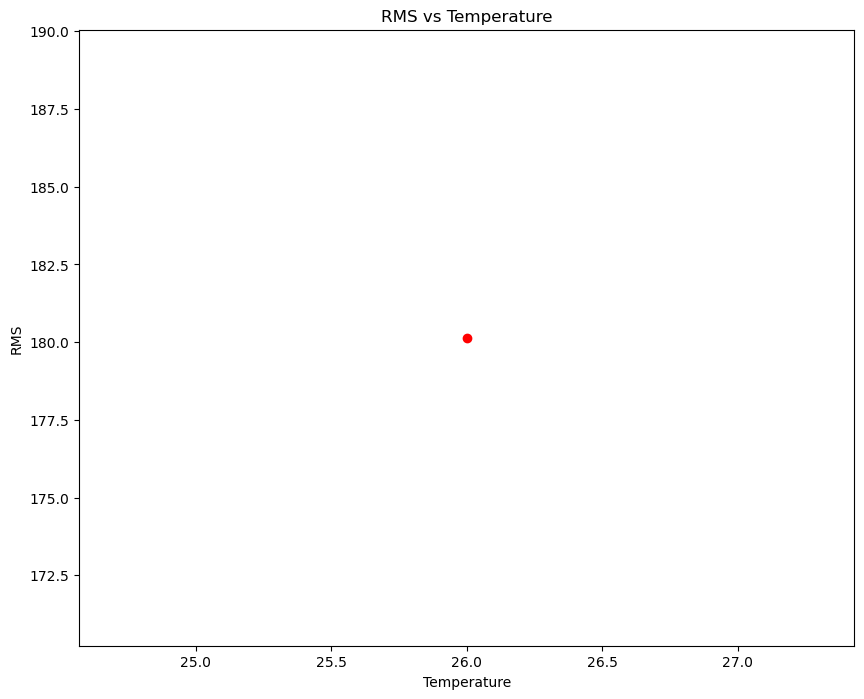

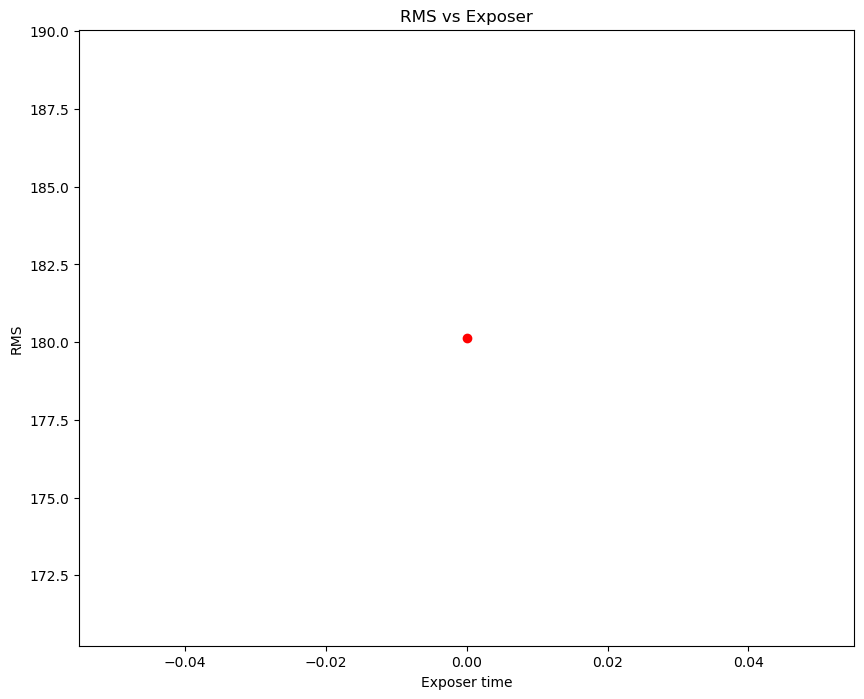

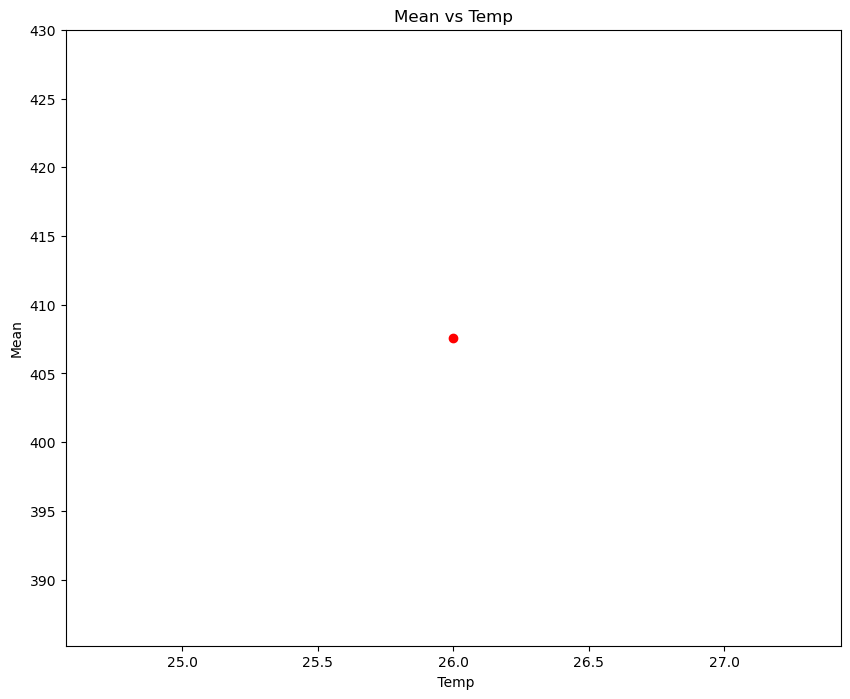

In [8]:
names = ['0s-dark-m10C.fit','0s-dark-m0C.fit','0s-dark-20C.fit','0s-dark-26C.fit','60s-dark-m10C.fit','100s-dark-26C.fit']
Temp = [ -10,0,20,26,-10,26]
Expose = [0,0,0,0,60,100]

names = ['0s-dark-26C.fit']
Temp = [ 26]
Expose = [0]


directory = "/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/"  # Replace with the path to your FITS files
fits_files = []
#Makeing fits_files list using names and directory
for name in names:
    fits_files.append(directory+name)
print(fits_files)


# names = ['0s-dark-26C.fit','100s-dark-26C.fit']
# Temp = [ 26,26]
# Expose = [0,100]

# directory = "/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/"  # Replace with the path to your FITS files
# fits_files = []
# #Makeing fits_files list using names and directory
# for name in names:
#     fits_files.append(directory+name)

mean = []

print(fits_files)
rms_list = []
for file_path in fits_files:
    print(file_path)
    with fits.open(file_path) as hdul:
        image_data = hdul[0].data  # Extract the image data

    image_min = np.min(image_data)
    image_max = np.max(image_data)
    rms_value = np.sqrt(np.mean(np.square(image_data)))
    rms_list.append(rms_value)
    mean.append(np.mean(image_data))


    # Print min, max, and RMS for reference
    print(f"Min: {image_min}, Max: {image_max}, RMS: {rms_value}")

#plot the RMs vs temp
plt.figure(figsize=(10, 8))
plt.plot(Temp,rms_list,"-g")
plt.plot(Temp,rms_list,"or")

plt.xlabel('Temperature')
plt.ylabel('RMS')
plt.title('RMS vs Temperature')
plt.show()

#plot the RMs vs exp
plt.figure(figsize=(10, 8))
plt.plot(Expose,rms_list,"-g")
plt.plot(Expose,rms_list,"or")

plt.xlabel('Exposer time')
plt.ylabel('RMS')
plt.title('RMS vs Exposer')
plt.show()

#plot the Temp vs mean
plt.figure(figsize=(10, 8))
plt.plot(Temp,mean,"-g")
plt.plot(Temp,mean,"or")

plt.xlabel(' Temp')
plt.ylabel('Mean')
plt.title('Mean vs Temp')
plt.show()

['/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit']
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/0s-dark-26C.fit


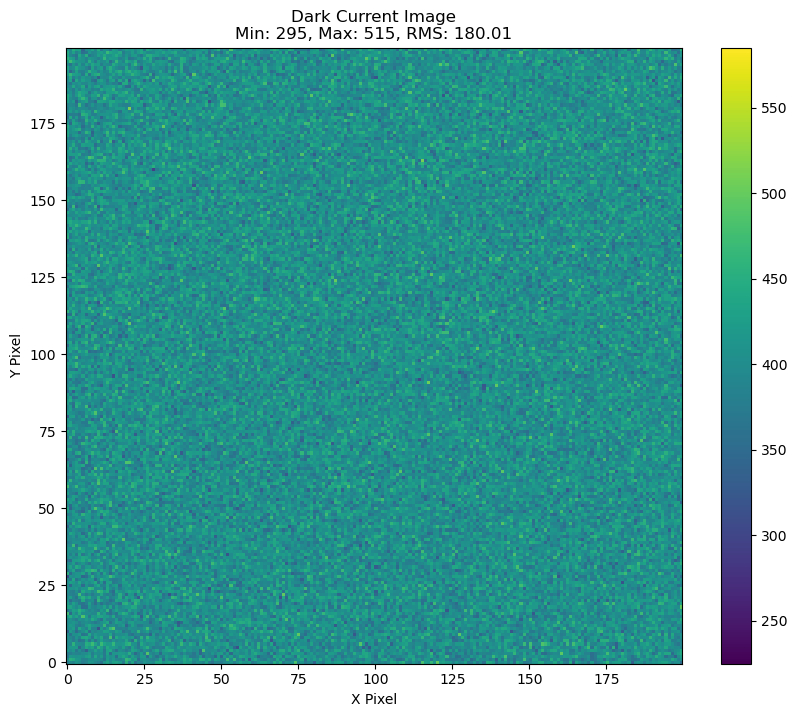

Min: 295, Max: 515, RMS: 180.00713388641017


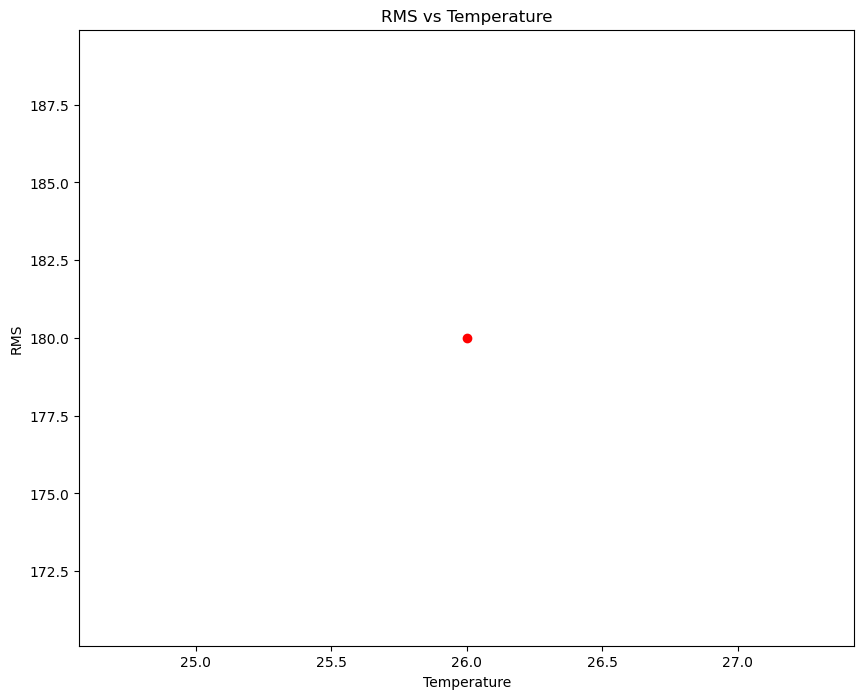

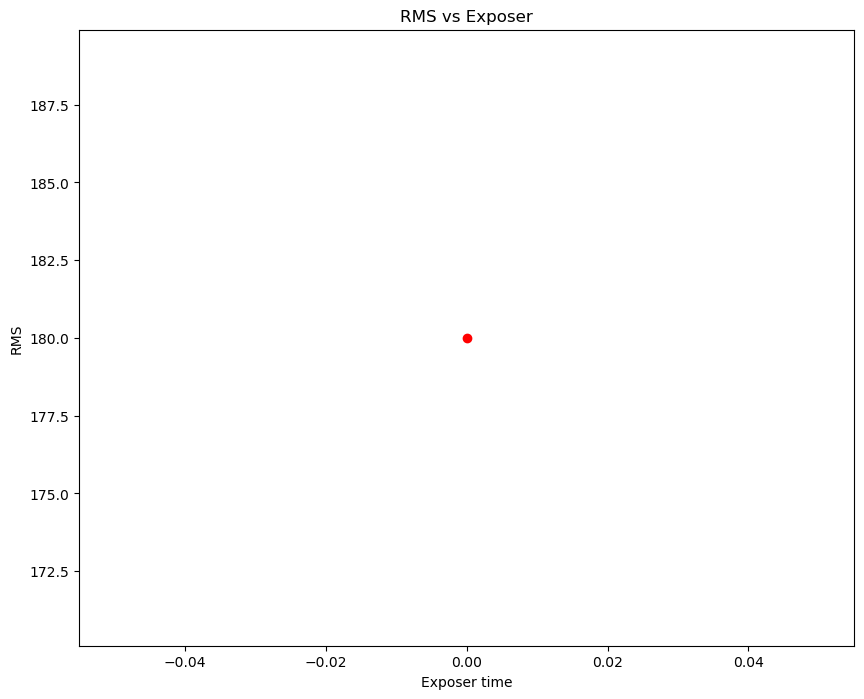

In [6]:
mid = [int(2529/2), int(3354/2)]
intrested = [mid[0]-100,mid[0]+100,mid[1]-100,mid[1]+100]
mean = []
print(fits_files)
rms_list = []
for file_path in fits_files:
    print(file_path)
    with fits.open(file_path) as hdul:
        image_data = hdul[0].data[mid[0]-100:mid[0]+100,mid[1]-100:mid[1]+100]  # Extract the image data

    image_min = np.min(image_data)
    image_max = np.max(image_data)
    rms_value = np.sqrt(np.mean(np.square(image_data)))
    rms_list.append(rms_value)


    # Adjust vmin and vmax for better contrast
    vmin = np.median(image_data) - rms_value
    vmax = np.median(image_data) + rms_value

    # Step 2: Plot the image
    plt.figure(figsize=(10, 8))
    plt.imshow(image_data, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)  # Scale using RMS around the median
    plt.imshow(image_data, cmap='viridis', origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))


    #plt.imshow(image_data, cmap='viridis', origin='lower', norm=PowerNorm(gamma=1, vmin=vmin, vmax=vmax))

    #plt.imshow(image_data, cmap='viridis', origin='lower', norm=SymLogNorm(linthresh=1000, vmin=vmin, vmax=vmax))



    plt.colorbar()
    plt.title(f'Dark Current Image\nMin: {image_min}, Max: {image_max}, RMS: {rms_value:.2f}')
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.show()

    # Print min, max, and RMS for reference
    print(f"Min: {image_min}, Max: {image_max}, RMS: {rms_value}")

#plot the RMs vs temp
plt.figure(figsize=(10, 8))
plt.plot(Temp,rms_list,"-g")
plt.plot(Temp,rms_list,"or")

plt.xlabel('Temperature')
plt.ylabel('RMS')
plt.title('RMS vs Temperature')
plt.show()

#plot the RMs vs exp
plt.figure(figsize=(10, 8))
plt.plot(Expose,rms_list,"-g")
plt.plot(Expose,rms_list,"or")

plt.xlabel('Exposer time')
plt.ylabel('RMS')
plt.title('RMS vs Exposer')
plt.show()

In [7]:
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm



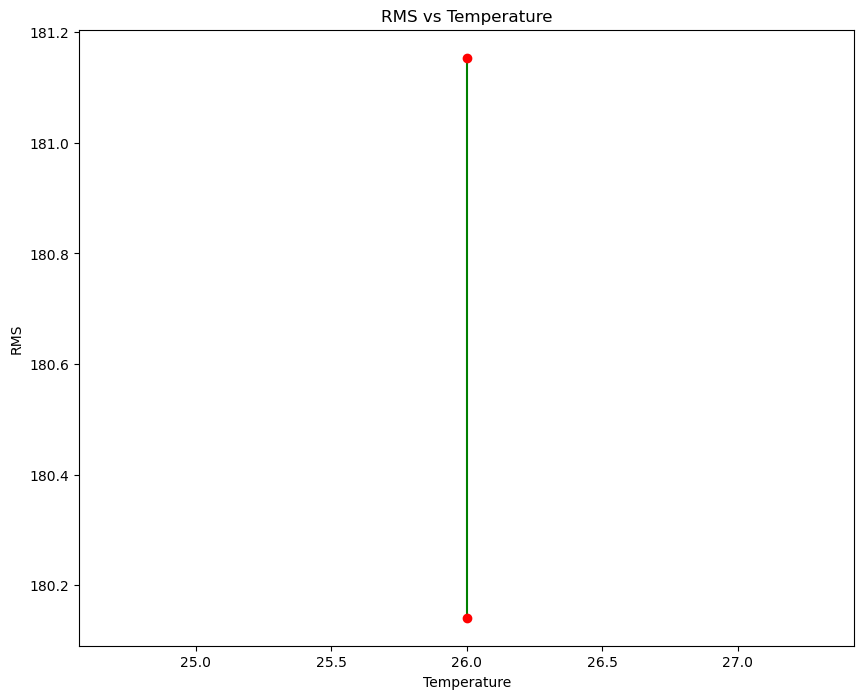

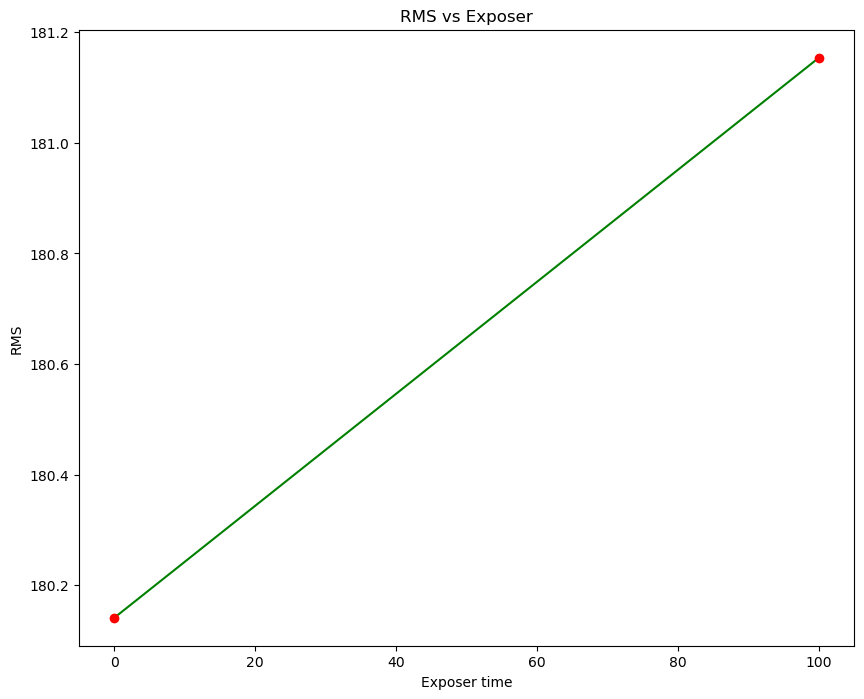

In [55]:
#plot the RMs vs temp
plt.figure(figsize=(10, 8))
plt.plot(Temp,rms_list,"-g")
plt.plot(Temp,rms_list,"or")

plt.xlabel('Temperature')
plt.ylabel('RMS')
plt.title('RMS vs Temperature')
plt.show()

#plot the RMs vs exp
plt.figure(figsize=(10, 8))
plt.plot(Expose,rms_list,"-g")
plt.plot(Expose,rms_list,"or")

plt.xlabel('Exposer time')
plt.ylabel('RMS')
plt.title('RMS vs Exposer')
plt.show()

In [3]:
import re
import os
def list_fits_files(directory):
    fits_files = []
    for file in os.listdir(directory):
        if file.endswith(".fit") or file.endswith(".fits"):
            #fits_files.append(os.path.join(directory, file))  # add full path
            fits_files.append(file)  # add full path
    return fits_files

In [43]:

def extract_exposure_and_temperature_v2(filenames):
    extracted_exposer = []
    extracted_temp = []
    filename_list = []
    
    for filename in filenames:
        # Regular expression to extract exposure time and temperature (with p or m for temperature)
        match = re.search(r'(\d+)s_[\w-]*_(p|m)_(\d+)c', filename)
        
        if match:
            if match.group(1) != '60':
                continue
            print(match.group(0))
            print(match.group(3))
            exposure_time = int(match.group(1))  # Group 1 is the exposure time
            temp_sign = -1 if match.group(2) == 'm' else 1  # Group 2 is 'm' or 'p' for negative/positive temperature
            temperature = temp_sign * int(match.group(3))  # Group 3 is the temperature value
            
            extracted_exposer.append(exposure_time)
            extracted_temp.append(temperature)
            filename_list.append(filename)

    
    return filename_list,extracted_exposer,extracted_temp

directory = "/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data"  # Replace with the path to your FITS files
# Example list of file names
file_list = list_fits_files(directory)

# Extract exposure time and temperature
filename_list,exposure,temp = extract_exposure_and_temperature_v2(file_list)

# Sorting based on array1
sorted_arrays = sorted(zip(temp, filename_list, exposure))

# Unzip the sorted arrays
array1_sorted, array2_sorted, array3_sorted = zip(*sorted_arrays)

# Convert back to lists (if needed)
temp = list(array1_sorted)
filename_list = list(array2_sorted)
exposure = list(array3_sorted)


# Print the results
for i in range(len(filename_list)):
    print(f"File: {filename_list[i]}, Exposure Time: {exposure[i]}s, Temperature: {temp[i]}°C")


60s_dark_p_5c
5
60s_dark_p_0c
0
60s_dark_m_10c
10
60s_dark_m_10c
10
60s_dark_p_15c
15
60s_dark_m_10c
10
60s_dark_m_5c
5
60s_dark_p_10c
10
60s_dark_p_20c
20
File: 60s_dark_m_10c.fit, Exposure Time: 60s, Temperature: -10°C
File: 60s_dark_m_10c_000.fit, Exposure Time: 60s, Temperature: -10°C
File: 60s_dark_m_10c_7.fit, Exposure Time: 60s, Temperature: -10°C
File: 60s_dark_m_5c_6.fit, Exposure Time: 60s, Temperature: -5°C
File: 60s_dark_p_0c_5.fit, Exposure Time: 60s, Temperature: 0°C
File: 60s_dark_p_5c_4.fit, Exposure Time: 60s, Temperature: 5°C
File: 60s_dark_p_10c_3.fit, Exposure Time: 60s, Temperature: 10°C
File: 60s_dark_p_15c2.fit, Exposure Time: 60s, Temperature: 15°C
File: 60s_dark_p_20c_001.fit, Exposure Time: 60s, Temperature: 20°C


/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_m_10c.fit
Min: 217, Max: 65535, RMS: 348.7131663099758
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_m_10c_000.fit
Min: 217, Max: 65535, RMS: 342.9529900638389
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_m_10c_7.fit
Min: 215, Max: 65535, RMS: 342.8543421939707
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_m_5c_6.fit
Min: 216, Max: 65535, RMS: 347.06614217372714
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_p_0c_5.fit
Min: 214, Max: 65535, RMS: 355.0655756384269
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_p_5c_4.fit
Min: 214, Max: 65535, RMS: 366.89379669912984
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_p_10c_3.fit
Min: 219, Max: 65535, RMS: 389.07322364343474
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_dark_p_15c2.fit
Min: 241, Max: 65535, RMS: 427.8174262957614
/home/ashwin/GIT/IITK_notebooks/Optics Lab/ccd_data/60s_d

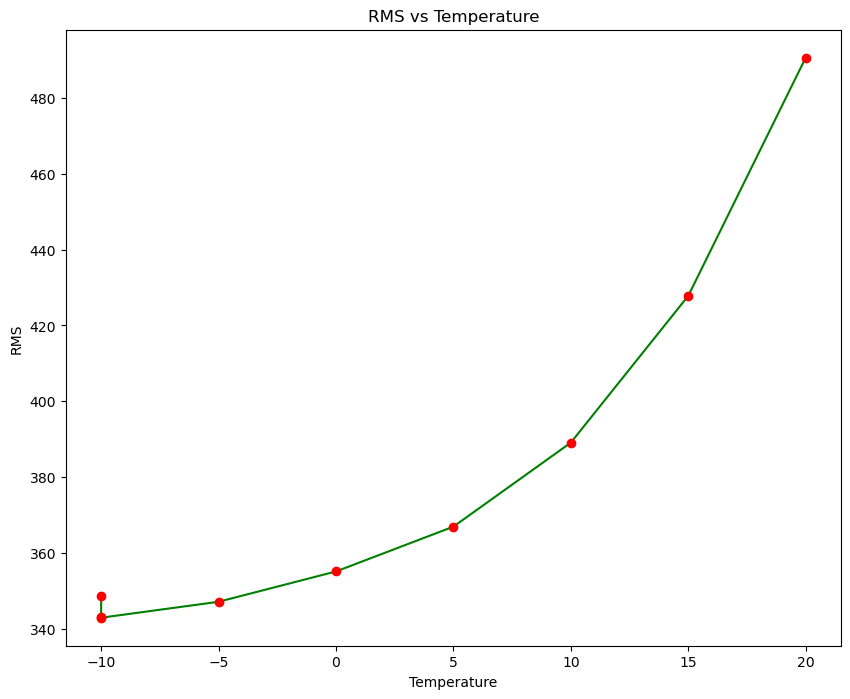

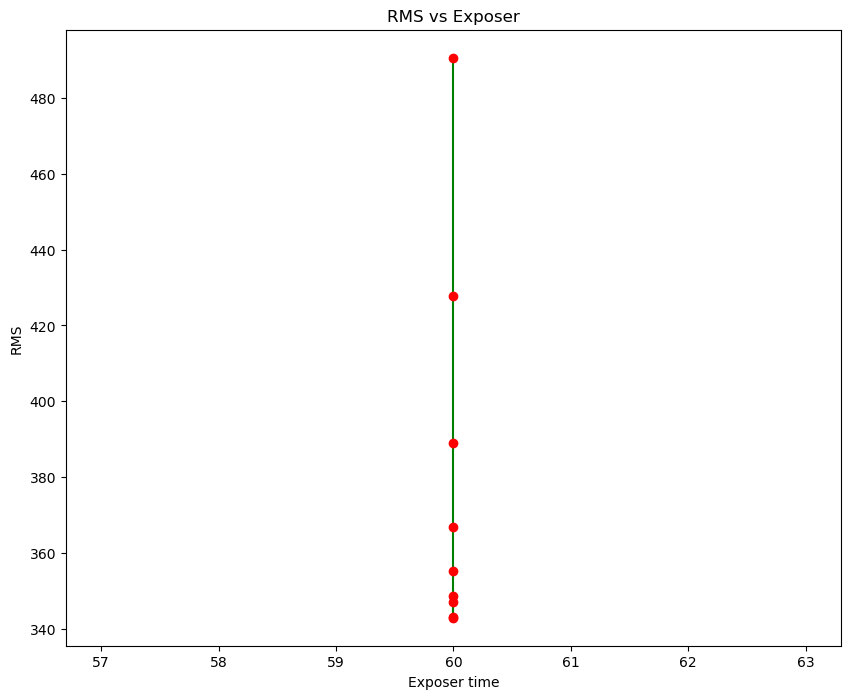

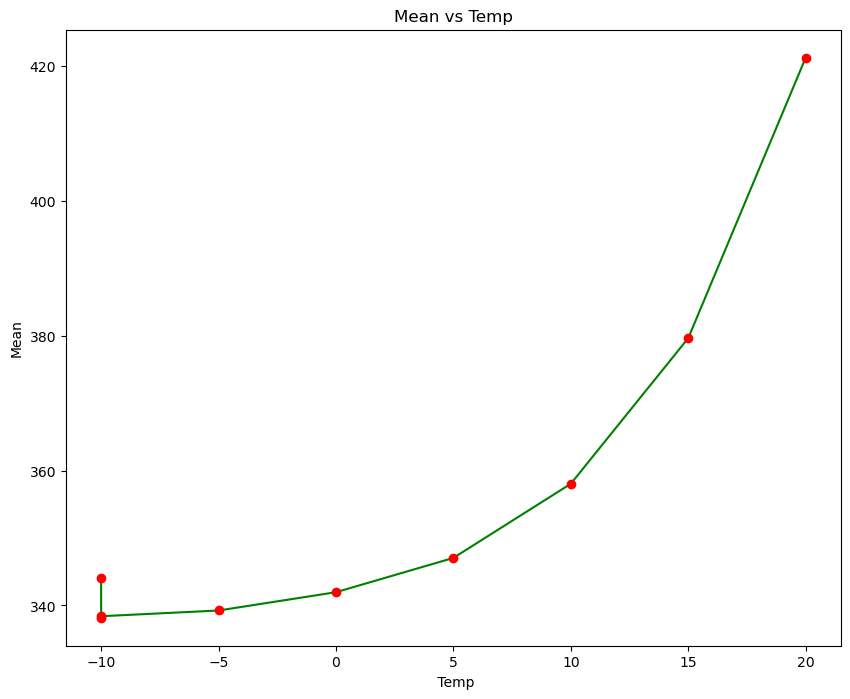

In [44]:

mean = []

rms_list = []
for file_path in filename_list:
    file_path = directory + '/' + file_path
    print(file_path)
    with fits.open(file_path) as hdul:
        image_data = hdul[0].data  # Extract the image data

        image_min = np.min(image_data)
        image_max = np.max(image_data)
        rms_value = np.sqrt(np.mean(np.abs(np.square(image_data))))
        rms_value = np.sqrt( np.square(np.mean(image_data) ) + np.var(image_data) )
        rms_list.append(rms_value)
        mean.append(np.mean(image_data))

        # Print min, max, and RMS for reference
        print(f"Min: {image_min}, Max: {image_max}, RMS: {rms_value}")

#plot the RMs vs temp
plt.figure(figsize=(10, 8))
plt.plot(temp,rms_list,"-g")
plt.plot(temp,rms_list,"or")

plt.xlabel('Temperature')
plt.ylabel('RMS')
plt.title('RMS vs Temperature')
plt.show()

#plot the RMs vs exp
plt.figure(figsize=(10, 8))
plt.plot(exposure,rms_list,"-g")
plt.plot(exposure,rms_list,"or")

plt.xlabel('Exposer time')
plt.ylabel('RMS')
plt.title('RMS vs Exposer')
plt.show()

#plot the Temp vs mean
plt.figure(figsize=(10, 8))
plt.plot(temp,mean,"-g")
plt.plot(temp,mean,"or")

plt.xlabel(' Temp')
plt.ylabel('Mean')
plt.title('Mean vs Temp')
plt.show()

In [33]:
import cv2

print(filename_list)


print("Mean value:",  np.sqrt(np.mean(np.square(image_data))))

rms_value = np.sqrt(np.nanmean(np.square(image_data)))
print("rms value:", rms_value)
print("Min:",  np.min(image_data))

print("Max:",  np.max(image_data))
print("mean:",  np.mean(image_data))
print("std:",  np.std(image_data))
print("median:",  np.median(image_data))

print("Variance:",  np.var(image_data))
print("var",np.sqrt( np.sum(np.square(image_data))/len(image_data)/len(image_data[0]) ) )

['60s_dark_p_5c_4.fit', '0s_dark_p_20c.fit', '100s_dark_p_26c.fit', '60s_dark_p_0c_5.fit', '60s_dark_m_10c_000.fit', '60s_dark_m_10c.fit', '60s_dark_p_15c2.fit', '0s_dark_m_10c.fit', '60s_dark_m_10c_7.fit', '60s_dark_m_5c_6.fit', '60s_dark_p_10c_3.fit', '60s_dark_p_20c_001.fit', '0s_dark_m_0c.fit']
Mean value: 195.97644020754265
rms value: 195.97644020754265
Min: 208
Max: 1828
mean: 336.56590196534745
std: 26.367984764545074
median: 336.0
Variance: 695.2706205432812
var 195.97644020754265


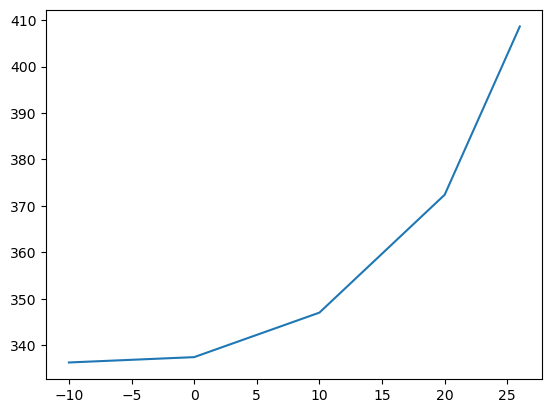

In [13]:
plt.plot([26,20,10,0,-10],[408.62,372.4,347.041,337.463,336.313])